## Thư viện

In [1]:
import os
import json
import time
import re
import random
from collections import defaultdict, Counter

import requests
from PIL import Image

import google.generativeai as genai
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

C:\Users\HP\AppData\Local\Temp\ipykernel_22756\3252296750.py:11: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


## Thống kê dữ liệu trước khi tạo QA

In [2]:
count = 0
for folder in os.listdir('data/images'):
    folder_path = os.path.join('data/images', folder)
    if os.path.isdir(folder_path):
        img_files = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
        print(f"{folder}: {len(img_files)} ảnh")
        count += len(img_files)
print(f"Tổng cộng: {count} ảnh")

bánh_canh: 40 ảnh
bánh_cuốn: 40 ảnh
bánh_mì_Việt_Nam: 40 ảnh
bánh_xèo: 40 ảnh
bún_bò_Huế: 40 ảnh
bún_chả: 40 ảnh
bún_riêu: 40 ảnh
cháo_lòng: 40 ảnh
cơm_gà_Hội_An: 40 ảnh
cơm_tấm: 40 ảnh
gỏi_cuốn: 40 ảnh
hủ_tiếu: 40 ảnh
lẩu_Thái: 40 ảnh
mì_Quảng: 40 ảnh
phở_bò: 40 ảnh
Tổng cộng: 600 ảnh


## Thay đổi tên file theo đúng thứ tự từ 1 đến 40

In [11]:
for folder in os.listdir('data/images'):
    folder_path = os.path.join('data/images', folder)
    if os.path.isdir(folder_path):
        img_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        img_files.sort()  # Sắp xếp để thứ tự ổn định
        for idx, filename in enumerate(img_files, 1):
            ext = os.path.splitext(filename)[1].lower()
            new_name = f"{idx:06d}{ext}"
            src = os.path.join(folder_path, filename)
            dst = os.path.join(folder_path, new_name)
            if src != dst:
                os.rename(src, dst)

## Tạo QA bằng germini

In [ ]:
GEMINI_API_KEY = "" 
TARGET_PER_FOOD  = 40 # số ảnh hợp lệ mục tiêu cho mỗi món
QA_PER_IMAGE     = 5 # số cặp Q&A sinh ra cho mỗi ảnh
IMAGE_DIR        = "data/images" # thư mục lưu ảnh
CHECKPOINT_FILE  = "data/checkpoint.json" # file lưu tiến độ sinh Q&A
OUTPUT_RAW       = "data/dataset_raw.json"# dataset thô toàn bộ

# Tạo thư mục nếu chưa có
os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs("data", exist_ok=True)

# Khởi tạo Gemini client
genai.configure(api_key=GEMINI_API_KEY)
model = genai.GenerativeModel("gemini-2.5-flash")
print("Cấu hình xong")

Cấu hình xong


In [ ]:
# PROMPT SINH Q&A — yêu cầu Gemini tạo 5 loại câu hỏi khác nhau
# Đa dạng loại câu hỏi giúp model VQA học được nhiều kỹ năng:
#   recognition : nhận dạng tên món
#   color       : nhận biết màu sắc
#   counting    : đếm số lượng
#   yes_no      : câu hỏi có/không
#   ingredient  : nhận biết thành phần

QA_PROMPT = """Bạn là chuyên gia ẩm thực Việt Nam. Nhìn vào ảnh món ăn này.
Tạo đúng 5 cặp câu hỏi - câu trả lời tiếng Việt theo 5 loại sau:

1. recognition : "Đây là món gì?" hoặc "Món ăn trong ảnh tên là gì?"
2. color       : hỏi về màu sắc của một thành phần nhìn thấy rõ trong ảnh
3. counting    : hỏi đếm số lượng thứ gì đó nhìn thấy (đĩa, chén, miếng...)
4. yes_no      : câu hỏi có/không (VD: "Có rau sống không?", "Có nước chấm không?")
5. ingredient  : hỏi tên một nguyên liệu nhìn thấy trong ảnh

Quy tắc:
- Câu trả lời ≤ 10 từ, ngắn gọn, không giải thích
- CHỈ hỏi những gì NHÌN THẤY RÕ trong ảnh, không đoán mò
- Trả về JSON thuần túy, không thêm markdown hay giải thích

Format JSON:
[
    {"type": "recognition", "question": "...", "answer": "..."},
    {"type": "color",       "question": "...", "answer": "..."},
    {"type": "counting",    "question": "...", "answer": "..."},
    {"type": "yes_no",      "question": "...", "answer": "..."},
    {"type": "ingredient",  "question": "...", "answer": "..."}
]"""


# Hàm xử lý trường hợp Gemini trả về JSON bọc trong markdown code block hoặc có text thừa
def safe_parse_json(text):
    # Xóa markdown code block nếu có (```json ... ```)
    text = re.sub(r"```json|```", "", text).strip()
    # Tìm array JSON trong text
    match = re.search(r"\[.*\]", text, re.DOTALL)
    if match:
        return json.loads(match.group())
    raise ValueError(f"Không parse được JSON: {text[:200]}")


# Hàm sinh Q&A cho 1 ảnh trả về list các dict {image_path, label, type, question, answer}
def generate_qa(image_path, food_label):
    img      = Image.open(image_path).convert("RGB")
    response = model.generate_content([QA_PROMPT, img])
    qa_list  = safe_parse_json(response.text)

    results = []
    for qa in qa_list:
        results.append({
            "image_path": image_path,
            "label"     : food_label,
            "type"      : qa.get("type", ""),
            "question"  : qa["question"],
            "answer"    : qa["answer"]
        })
    return results


print("Định nghĩa hàm sinh Q&A xong!")

Định nghĩa hàm sinh Q&A.


**Chạy qua các ảnh và tạo QA, có checkpoint để lưu quá trình chạy**

In [ ]:
IMAGE_DIR       = "data/images"
CHECKPOINT_FILE = "data/checkpoint.json"
OUTPUT_RAW      = "data/dataset_raw.json"

FOODS = [
    "bánh mì Việt Nam", "phở bò", "bún bò Huế", "cơm tấm",
    "bánh xèo", "gỏi cuốn", "bún chả", "hủ tiếu",
    "bánh cuốn", "cháo lòng", "mì Quảng", "bún riêu",
    "bánh canh", "lẩu Thái", "cơm gà Hội An"
]

# Load checkpoint nếu đã chạy dở
if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE, encoding="utf-8") as f:
        checkpoint = json.load(f)
    all_data    = checkpoint["data"]
    done_images = set(checkpoint["done_images"])
    print(f"Tiếp tục từ checkpoint: {len(done_images)} ảnh đã xử lý")
else:
    all_data    = []
    done_images = set()
    print("Sinh từ đầu")

print("\nBắt đầu sinh Q&A...\n")

for food_name in FOODS:
    # Tên folder dùng dấu _ thay dấu cách
    food_slug  = food_name.replace(" ", "_")
    folder     = os.path.join(IMAGE_DIR, food_slug)

    if not os.path.exists(folder):
        print(f"[{food_name}]: không tìm thấy folder, bỏ qua")
        continue

    images = [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print(f"[{food_name}] ({len(images)} ảnh)")

    for img_path in images:
        # Bỏ qua ảnh đã sinh Q&A
        if img_path in done_images:
            continue

        try:
            qa_pairs = generate_qa(img_path, food_name)  # FIX: dùng food_name thay food_label
            all_data.extend(qa_pairs)
            done_images.add(img_path)

            # Lưu checkpoint sau mỗi ảnh
            with open(CHECKPOINT_FILE, "w", encoding="utf-8") as f:
                json.dump(
                    {"data": all_data, "done_images": list(done_images)},
                    f, ensure_ascii=False
                )

            print(f"  {os.path.basename(img_path)}: {len(qa_pairs)} Q&A")

        except Exception as e:
            print(f"  Loi {os.path.basename(img_path)}: {e}")
            time.sleep(10)
            continue

        time.sleep(2)

# Lưu dataset thô toàn bộ
with open(OUTPUT_RAW, "w", encoding="utf-8") as f:
    json.dump(all_data, f, ensure_ascii=False, indent=2)

print(f"\nSinh Q&A xong: {len(all_data)} bộ")
print(f"Lưu tại: {OUTPUT_RAW}")

### Chia dữ liệu thành các tập trai/val/test

In [5]:
# KIỂM TRA CHẤT LƯỢNG DATASET
# Hiển thị thống kê tổng quan và phát hiện vấn đề
with open('data/dataset_raw.json', encoding="utf-8") as f:
    data = json.load(f)

print("THỐNG KÊ DATASET")
print(f"Tổng số bộ Q&A: {len(data)}")
print(f"Số ảnh duy nhất: {len(set(d['image_path'] for d in data))}")
print(f"Số nhãn món ăn: {len(set(d['label'] for d in data))}")

# Phân phối theo nhãn
print("\nPhân phối theo món:")
labels = Counter(d["label"] for d in data)
for label, count in sorted(labels.items(), key=lambda x: -x[1]):
    bar = "█" * (count // 10)
    print(f"  {label:<25} {count:>4} bộ  {bar}")

# Phân phối theo loại câu hỏi
print("\nPhân phối theo loại câu hỏi:")
types = Counter(d.get("type", "unknown") for d in data)
for t, count in types.most_common():
    print(f"  {t:<15} : {count} câu ({count/len(data)*100:.1f}%)")

# Kiểm tra câu trả lời quá dài
long_ans = [d for d in data if len(d["answer"].split()) > 5]
print(f"\nCâu trả lời > 5 từ: {len(long_ans)}")
if long_ans:
    print("   Ví dụ:")
    for d in long_ans[:3]:
        print(f"   Q: {d['question']}")
        print(f"   A: {d['answer']}")
        print()

# Kiểm tra câu hỏi trùng lặp hoàn toàn
questions = [d["question"] for d in data]
dup_count = len(questions) - len(set(questions))
print(f"Câu hỏi trùng lặp: {dup_count} ({dup_count/len(data)*100:.1f}%)")

# Xem mẫu ngẫu nhiên
print("\n Mẫu ngẫu nhiên (3 bộ):")
for sample in random.sample(data, min(3, len(data))):
    print(f"  [{sample['label']}] ({sample.get('type','')}")
    print(f"  Q: {sample['question']}")
    print(f"  A: {sample['answer']}")
    print()

THỐNG KÊ DATASET
Tổng số bộ Q&A: 3000
Số ảnh duy nhất: 600
Số nhãn món ăn: 15

Phân phối theo món:
  bánh mì Việt Nam           200 bộ  ████████████████████
  phở bò                     200 bộ  ████████████████████
  bún bò Huế                 200 bộ  ████████████████████
  cơm tấm                    200 bộ  ████████████████████
  bánh xèo                   200 bộ  ████████████████████
  gỏi cuốn                   200 bộ  ████████████████████
  bún chả                    200 bộ  ████████████████████
  hủ tiếu                    200 bộ  ████████████████████
  bánh cuốn                  200 bộ  ████████████████████
  cháo lòng                  200 bộ  ████████████████████
  mì Quảng                   200 bộ  ████████████████████
  bún riêu                   200 bộ  ████████████████████
  bánh canh                  200 bộ  ████████████████████
  lẩu Thái                   200 bộ  ████████████████████
  cơm gà Hội An              200 bộ  ████████████████████

Phân phối theo loại câu hỏi:
 

In [12]:
# CHIA DATASET THEO ẢNH (image-level split)

with open('data/dataset_raw.json', encoding="utf-8") as f:
    data = json.load(f)

# Group các Q&A theo ảnh
by_image = defaultdict(list)
for item in data:
    by_image[item["image_path"]].append(item)

# Shuffle danh sách ảnh (seed cố định để tái tạo được)
images = list(by_image.keys())
random.seed(42)
random.shuffle(images)

# Tính điểm cắt 80% / 10% / 10%
n = len(images)
train_end = int(n * 0.8)
val_end = int(n * 0.9)

train_imgs = images[:train_end]
val_imgs = images[train_end:val_end]
test_imgs = images[val_end:]

# Hàm lấy Q&A từ danh sách ảnh
def get_split_data(img_list):
    result = []
    for img in img_list:
        result.extend(by_image[img])
    return result

splits = {
    "train": get_split_data(train_imgs),
    "val": get_split_data(val_imgs),
    "test": get_split_data(test_imgs),
}

# Lưu từng split
for split_name, split_data in splits.items():
    path = f"data/{split_name}.json"
    with open(path, "w", encoding="utf-8") as f:
        json.dump(split_data, f, ensure_ascii=False, indent=2)
    print(f"{split_name:5s}: {len(split_data):>5} bộ  ({len(set(d['image_path'] for d in split_data))} ảnh) → {path}")

print(f"\nTổng: {len(data)} bộ")
print("Dataset hoàn chỉnh!")

train:  2400 bộ  (480 ảnh) → data/train.json
val  :   300 bộ  (60 ảnh) → data/val.json
test :   300 bộ  (60 ảnh) → data/test.json

Tổng: 3000 bộ
Dataset hoàn chỉnh!


In [13]:
# IN CẤU TRÚC THƯ MỤC DATASET
FOODS = [
    "bánh mì Việt Nam", "phở bò", "bún bò Huế", "cơm tấm",
    "bánh xèo", "gỏi cuốn", "bún chả", "hủ tiếu",
    "bánh cuốn", "cháo lòng", "mì Quảng", "bún riêu",
    "bánh canh", "lẩu Thái", "cơm gà Hội An"
]
print("Cấu trúc thư mục:")
print("data/")
print("├── images/")
for food_name in FOODS:
    folder = os.path.join('data/images', food_name)
    if os.path.exists(folder):
        n_imgs = len([f for f in os.listdir(folder) if f.endswith((".jpg",".jpeg",".png"))])
        print(f"│   ├── {food_name}/  ({n_imgs} ảnh)")
print("├── dataset_raw.json")
print("├── train.json")
print("├── val.json")
print("└── test.json")


print("Cấu trúc 1 entry trong JSON:")

with open("data/train.json", encoding="utf-8") as f:
    sample = json.load(f)[0]

print(json.dumps(sample, ensure_ascii=False, indent=2))

Cấu trúc thư mục:
data/
├── images/
├── dataset_raw.json
├── train.json
├── val.json
└── test.json
Cấu trúc 1 entry trong JSON:
{
  "image_path": "data/images\\lẩu_Thái\\000016.jpg",
  "label": "lẩu Thái",
  "type": "recognition",
  "question": "Đây là món gì?",
  "answer": "Món lẩu."
}


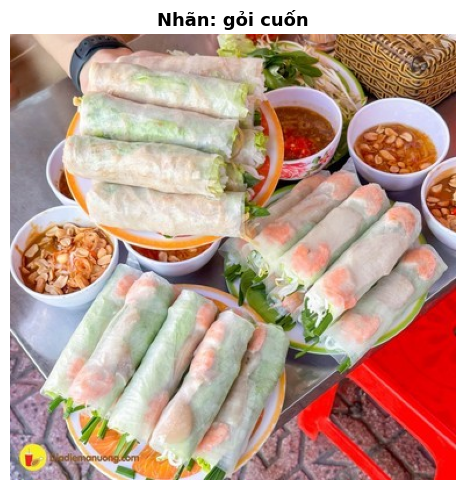


 Các câu hỏi cho ảnh này:
  [recognition ] Q: Đây là món gì?
                  A: Gỏi cuốn tôm.
  [color       ] Q: Tôm trong cuốn có màu gì?
                  A: Màu hồng cam.
  [counting    ] Q: Có bao nhiêu đĩa gỏi cuốn trong ảnh?
                  A: Ba đĩa.
  [yes_no      ] Q: Có nước chấm ăn kèm không?
                  A: Có.
  [ingredient  ] Q: Nguyên liệu chính màu hồng cam trong cuốn là gì?
                  A: Tôm.


In [16]:
# HIỂN THỊ MẪU ẢNH + Q&A từ test set

with open("data/test.json", encoding="utf-8") as f:
    test_data = json.load(f)

# Lấy 1 ảnh ngẫu nhiên từ test set
sample_img = random.choice(list(set(d["image_path"] for d in test_data)))
sample_qas = [d for d in test_data if d["image_path"] == sample_img]

# Hiển thị
fig, ax = plt.subplots(figsize=(6, 5))
img = Image.open(sample_img)
ax.imshow(img)
ax.axis("off")
ax.set_title(f"Nhãn: {sample_qas[0]['label']}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n Các câu hỏi cho ảnh này:")
for qa in sample_qas:
    print(f"  [{qa.get('type',''):12s}] Q: {qa['question']}")
    print(f"                  A: {qa['answer']}")

### Biểu đồ phân tích dữ liệu

In [5]:
# Đọc dữ liệu
with open('data/dataset_raw.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# Thống kê số ảnh và số câu hỏi theo từng món ăn
dish_to_images = defaultdict(set)
dish_to_questions = defaultdict(int)
question_type_count = Counter()

for item in data:
    dish = item['label']
    img = item['image_path']
    qtype = item['type']
    dish_to_images[dish].add(img)
    dish_to_questions[dish] += 1
    question_type_count[qtype] += 1

# Số ảnh theo món ăn
dish_image_counts = {k: len(v) for k, v in dish_to_images.items()}
# Số câu hỏi theo món ăn
dish_question_counts = dish_to_questions
# Số câu hỏi theo loại câu hỏi
qtype_counts = dict(question_type_count)


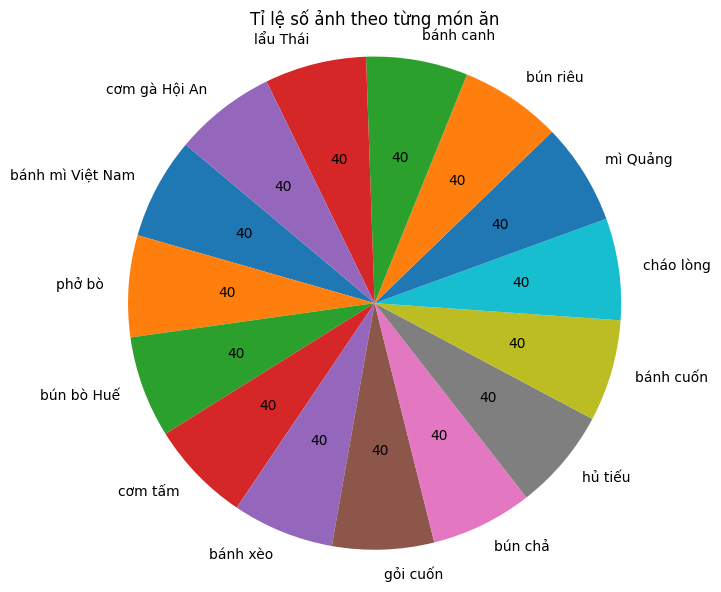

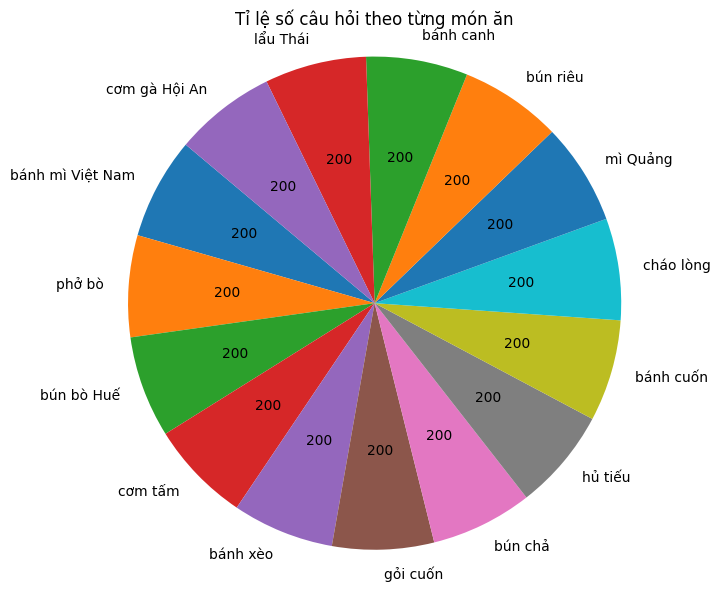

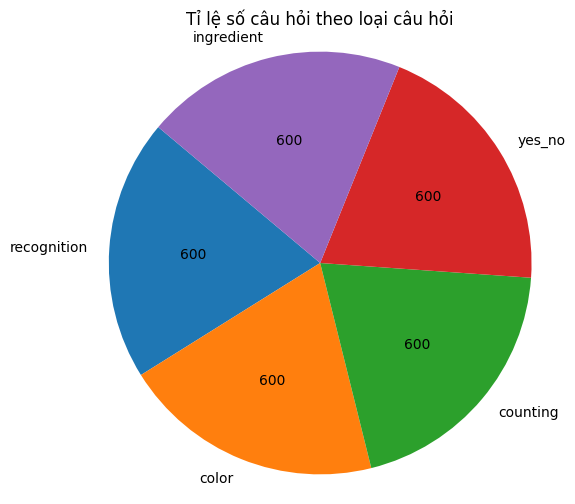

In [7]:
# Biểu đồ tròn
def make_pie_with_count(values, labels, title, figsize=(7,7)):
    def make_autopct(values):
        def my_autopct(pct):
            total = sum(values)
            count = int(round(pct*total/100.0))
            return f'{count}'
        return my_autopct
    plt.figure(figsize=figsize)
    plt.pie(values, labels=labels, autopct=make_autopct(values), startangle=140)
    plt.title(title)
    plt.axis('equal')
    plt.show()

make_pie_with_count(list(dish_image_counts.values()), list(dish_image_counts.keys()), 'Tỉ lệ số ảnh theo từng món ăn')
make_pie_with_count(list(dish_question_counts.values()), list(dish_question_counts.keys()), 'Tỉ lệ số câu hỏi theo từng món ăn')
make_pie_with_count(list(qtype_counts.values()), list(qtype_counts.keys()), 'Tỉ lệ số câu hỏi theo loại câu hỏi', figsize=(6,6))